In [1]:
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:


sns.set_style("whitegrid") #Arka plana hafif çizgiler ekler.

In [3]:
plt.rcParams['figure.figsize'] = (10, 6) # Tüm grafikleri varsayılan boyuta indiri.
plt.rcParams['font.size'] = 10 # Varsayılan font boyutu
plt.rcParams['figure.dpi'] = 100 #Grafik çözünürlüğü

In [4]:
df = pd.read_csv("cars.csv", index_col= 0)

In [5]:
df["Fiyat_TL"] = df["Fiyat_TL"].astype(str).str.replace(".", "").astype(int)

In [6]:
df.head()

,Marka,Model,Segment,Yakit_Tipi,Motor_Hacmi,Beygir,Tork,0_100_Hizlanma,Maks_Hiz,Ort_Yakit,Yil,Garanti,Fiyat_TL
ID,,,,,,,,,,,,,
1,Citroen,C3,Hatchback,Benzin,1.7,88,105,18.2,189,3.9,2020,Yok,1250000
2,Dacia,Sandero,Hatchback,Benzin,1.4,69,82,22.8,183,3.5,2024,Var,1450000
3,Ferrari,296 GTB,Spor,Benzin,3.7,995,1194,2.5,340,37.3,2020,Yok,58500000
4,Tesla,Model S,Sedan,Elektrik,0.0,243,364,6.7,241,0.0,2022,Yok,4800000
5,Audi,Q7,SUV,Benzin,1.3,210,252,7.4,230,9.2,2023,Var,9500000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Marka           200 non-null    object 
 1   Model           200 non-null    object 
 2   Segment         200 non-null    object 
 3   Yakit_Tipi      200 non-null    object 
 4   Motor_Hacmi     200 non-null    float64
 5   Beygir          200 non-null    int64  
 6   Tork            200 non-null    int64  
 7   0_100_Hizlanma  200 non-null    float64
 8   Maks_Hiz        200 non-null    int64  
 9   Ort_Yakit       200 non-null    float64
 10  Yil             200 non-null    int64  
 11  Garanti         200 non-null    object 
 12  Fiyat_TL        200 non-null    int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 21.9+ KB


Text(0.5, 1.0, 'Beygir gücü ve Fiyat ilişkisi tablo')

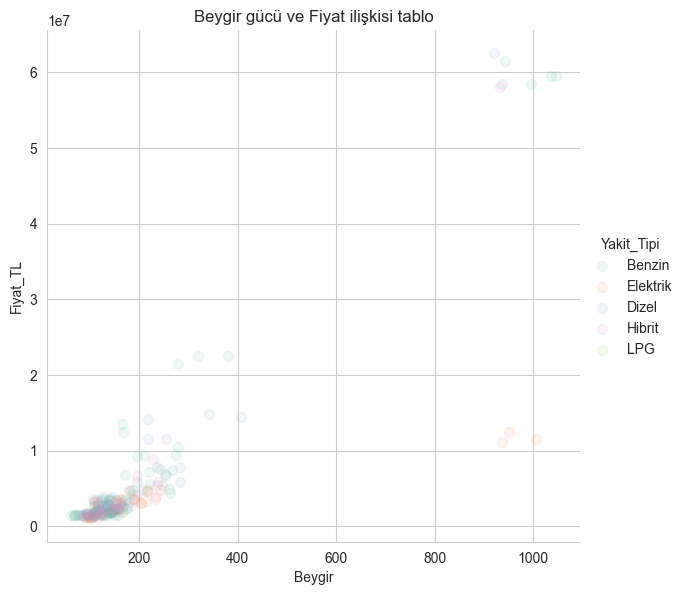

In [8]:
sns.lmplot(x= "Beygir",
           y = "Fiyat_TL", 
           data = df ,
           hue  ="Yakit_Tipi", #Noktaları yakıt tipine göre renklendirir
           fit_reg = False, #Regresyon çizgisini gizlemek için
           height = 6, #Grafiğin yüksekliği
           #aspect = 1.5 Genişlik / yükseklik oranı
           palette = 'Set2', #renk paleti
           scatter_kws = {"s": 50, "alpha": 0.1} # nokta boyutu : s değeri, seffaflık alpha
           )

plt.title("Beygir gücü ve Fiyat ilişkisi tablo")

<Axes: xlabel='Yakit_Tipi', ylabel='Beygir'>

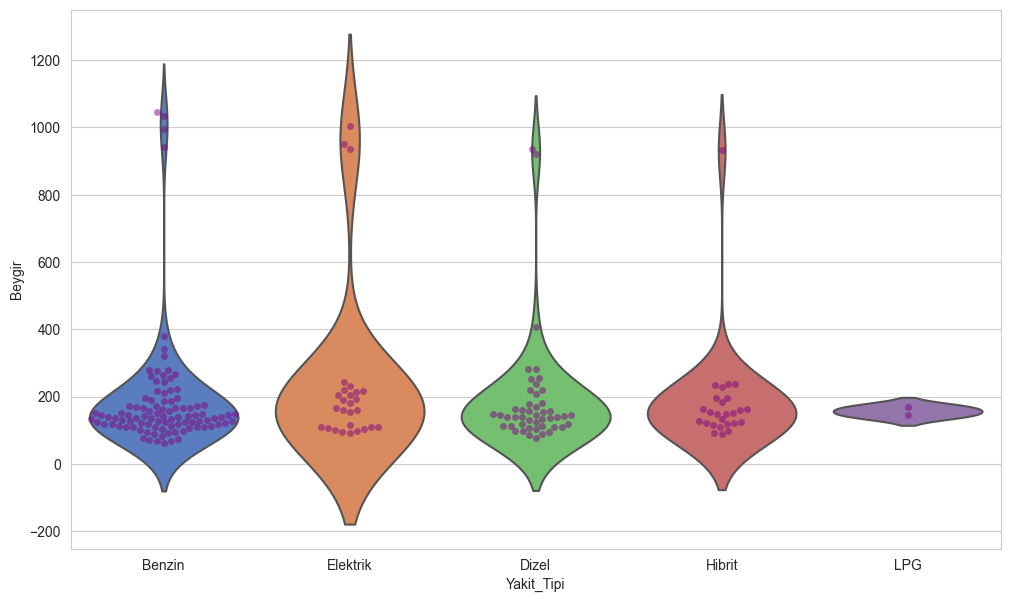

In [9]:
#Yakıt tipine göre beygir gücü dağılımı
plt.figure(figsize= (12, 7))

sns.violinplot(x = "Yakit_Tipi", 
               y = "Beygir",
               data = df,
               palette = "muted",
               inner = None,
               linewidth= 1.5
               
)

sns.swarmplot(x = "Yakit_Tipi", 
               y = "Beygir",
               data = df,
               color= "purple",
               alpha= 0.5,
               size= 5
)


In [10]:
#ilgilendiğimiz sütunlar

stats_df = df[["Marka", "Model", "Segment", "Beygir", "Tork"]]

df.head()

,Marka,Model,Segment,Yakit_Tipi,Motor_Hacmi,Beygir,Tork,0_100_Hizlanma,Maks_Hiz,Ort_Yakit,Yil,Garanti,Fiyat_TL
ID,,,,,,,,,,,,,
1,Citroen,C3,Hatchback,Benzin,1.7,88,105,18.2,189,3.9,2020,Yok,1250000
2,Dacia,Sandero,Hatchback,Benzin,1.4,69,82,22.8,183,3.5,2024,Var,1450000
3,Ferrari,296 GTB,Spor,Benzin,3.7,995,1194,2.5,340,37.3,2020,Yok,58500000
4,Tesla,Model S,Sedan,Elektrik,0.0,243,364,6.7,241,0.0,2022,Yok,4800000
5,Audi,Q7,SUV,Benzin,1.3,210,252,7.4,230,9.2,2023,Var,9500000


In [11]:
stats_df.head()

,Marka,Model,Segment,Beygir,Tork
ID,,,,,
1,Citroen,C3,Hatchback,88,105
2,Dacia,Sandero,Hatchback,69,82
3,Ferrari,296 GTB,Spor,995,1194
4,Tesla,Model S,Sedan,243,364
5,Audi,Q7,SUV,210,252


In [12]:
print(f"Şekil : {stats_df.shape}")


Şekil : (200, 5)


In [13]:
print(f"Orijinal Şekil : {df.shape}")

Orijinal Şekil : (200, 13)


In [14]:
#Melt işlemi : Beygir ve Tork sütunlartını "Özellik" adlı tek bir sütuna indiriyoruz.

melted_df = pd.melt(stats_df, 
                    id_vars= ["Marka", "Model", "Segment"],
                    value_vars= ["Beygir", "Tork"],
                    var_name= "Ozellik",
                    value_name = "Deger"
                    )

melted_df.head()

,Marka,Model,Segment,Ozellik,Deger
0,Citroen,C3,Hatchback,Beygir,88
1,Dacia,Sandero,Hatchback,Beygir,69
2,Ferrari,296 GTB,Spor,Beygir,995
3,Tesla,Model S,Sedan,Beygir,243
4,Audi,Q7,SUV,Beygir,210


In [15]:
print(melted_df.shape)

(400, 5)


<Axes: xlabel='Ozellik', ylabel='Deger'>

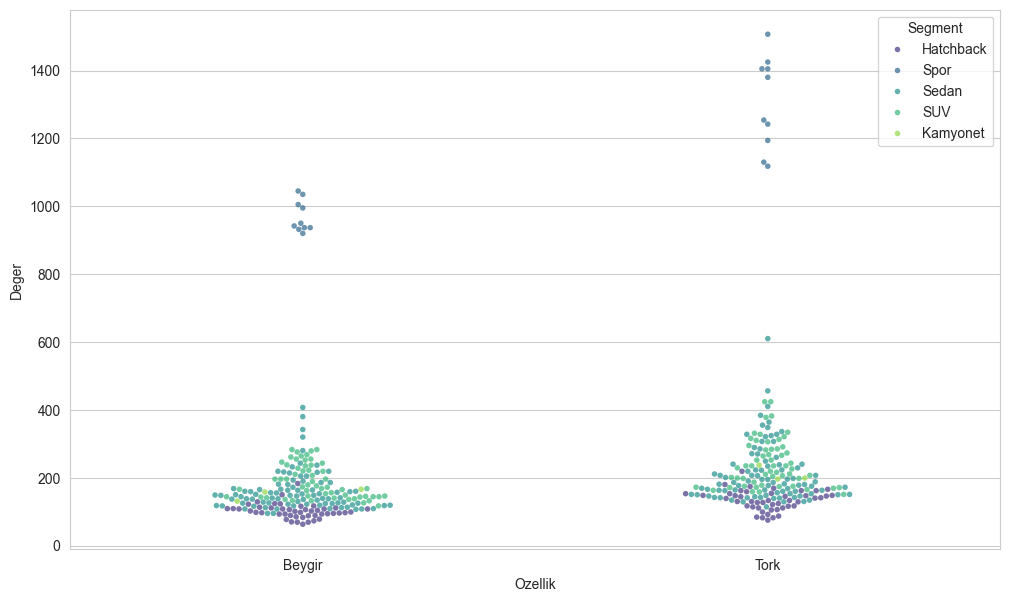

In [16]:
#Beygir ve tork karşılaştırması
plt.figure(figsize= (12, 7))

sns.swarmplot(x= "Ozellik", 
              y= "Deger",
              data= melted_df,
              hue= "Segment",
              palette= "viridis",
              size= 4,
              alpha= 0.7
              
              )

In [17]:
numeric_df = df.select_dtypes(include = ["float64", "int64"])

corr = numeric_df.corr() #korelasyon hesaplama ( -1 ve 1 aralıdönüştürme)
#corr değerlerin 0 ile 1 arasındaki ilişkiyi gösterir.
print(corr)

                Motor_Hacmi    Beygir      Tork  0_100_Hizlanma  Maks_Hiz  \
Motor_Hacmi        1.000000  0.285878  0.212694       -0.098485  0.251106   
Beygir             0.285878  1.000000  0.987509       -0.692446  0.958043   
Tork               0.212694  0.987509  1.000000       -0.685729  0.947069   
0_100_Hizlanma    -0.098485 -0.692446 -0.685729        1.000000 -0.831823   
Maks_Hiz           0.251106  0.958043  0.947069       -0.831823  1.000000   
Ort_Yakit          0.735717  0.712295  0.626925       -0.482934  0.691625   
Yil               -0.213452 -0.148402 -0.117042        0.128293 -0.127435   
Fiyat_TL           0.473930  0.869601  0.821432       -0.566215  0.828097   

                Ort_Yakit       Yil  Fiyat_TL  
Motor_Hacmi      0.735717 -0.213452  0.473930  
Beygir           0.712295 -0.148402  0.869601  
Tork             0.626925 -0.117042  0.821432  
0_100_Hizlanma  -0.482934  0.128293 -0.566215  
Maks_Hiz         0.691625 -0.127435  0.828097  
Ort_Yakit        1

<Axes: >

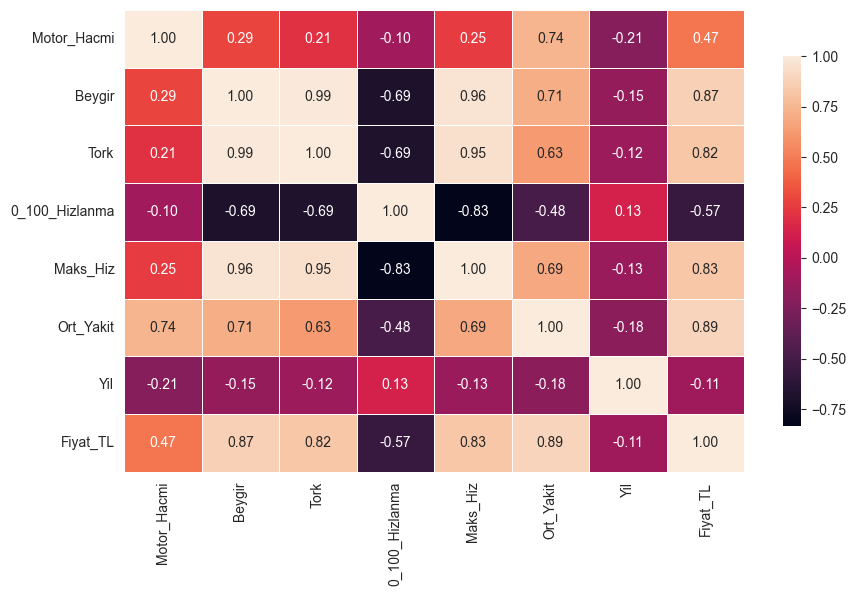

In [18]:
sns.heatmap(corr,
            annot = True, # Her kutucuğun içine sayısal değeri yazar
            fmt = ".2f", # Kutucuk içindeki sayıların formatı
            linewidths= 0.5, # Hücreler arasına ince çizgi (boşluk) koyar
            cbar_kws= {"shrink" : 0.8} # Sağdaki renk skalasını (colorbar) küçültür. Büyük grafiklerde taşmayı önler.
            )

<Axes: xlabel='Marka', ylabel='count'>

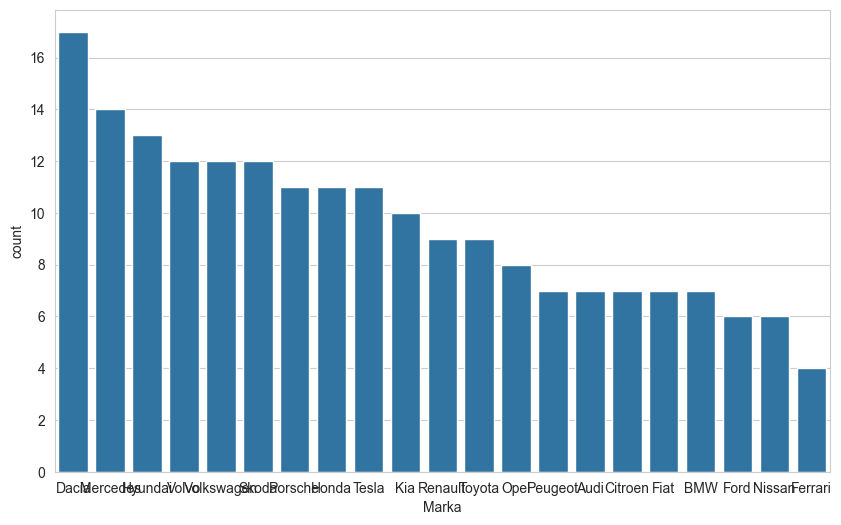

In [19]:
sns.countplot(x = "Marka", 
              data= df,
              order= df["Marka"].value_counts().index)

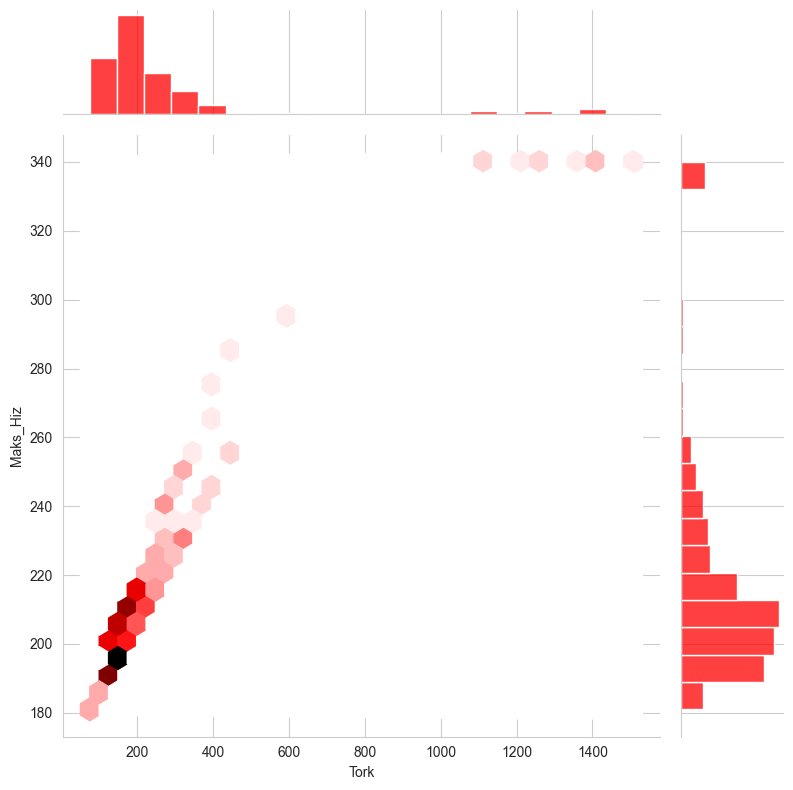

In [20]:
sns.jointplot(x= "Tork",
              y= "Maks_Hiz",
              data= df,
              kind= "hex",
              color= "red",
              height= 8,
              marginal_kws= dict(bins=20, fill = True))